## Experiment 4: Train the GAN on a dataset of images (e.g., MNIST, CIFAR-10) and monitor the generator and discriminator losses.

### 1. Environment Setup

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### 2. Data Loading and Preprocessing (MNIST)

In [4]:
# Define transformations for the MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(), # Convert PIL image to PyTorch tensor
    transforms.Normalize((0.5,), (0.5,)) # Normalize pixel values to range [-1, 1]
])

# Download and load the MNIST training dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Create a DataLoader for batching and shuffling
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of batches per epoch: {len(train_loader)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.36MB/s]

Number of training samples: 60000
Number of batches per epoch: 938


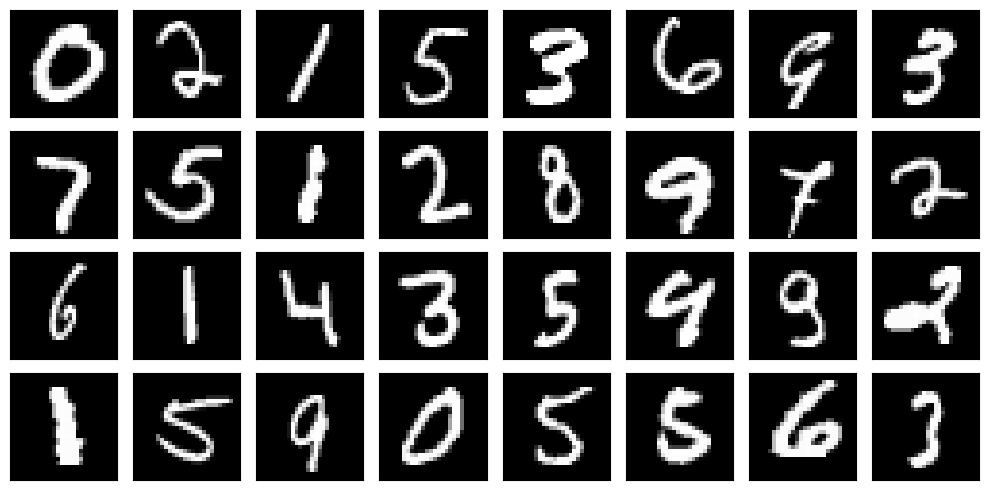

In [5]:
# Visualize some sample images from the dataset
def show_images(images, num_rows=4, num_cols=8, figsize=(10, 5)):
    fig = plt.figure(figsize=figsize)
    for i in range(min(num_rows * num_cols, len(images))):
        ax = fig.add_subplot(num_rows, num_cols, i + 1, xticks=[], yticks=[])
        image = images[i].cpu().numpy().squeeze() # Remove channel dimension if grayscale
        image = (image * 0.5) + 0.5 # Denormalize for display
        ax.imshow(image, cmap='gray')
    plt.tight_layout()
    plt.show()

# Get a batch of training data
sample_images, _ = next(iter(train_loader))
show_images(sample_images[:32])

### 3. Model Architecture (Generator and Discriminator)

In [6]:
# Generator Model
class Generator(nn.Module):
    def __init__(self, latent_dim, img_shape):
        super(Generator, self).__init__()
        self.img_shape = img_shape

        def block(in_feat, out_feat, normalize=True):
            layers = [nn.Linear(in_feat, out_feat)]
            if normalize:
                layers.append(nn.BatchNorm1d(out_feat, 0.8))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(latent_dim, 128, normalize=False),
            *block(128, 256),
            *block(256, 512),
            *block(512, 1024),
            nn.Linear(1024, int(np.prod(img_shape))),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), *self.img_shape)
        return img

# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self, img_shape):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(int(np.prod(img_shape)), 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

# Hyperparameters for GAN
img_shape = (1, 28, 28)  # MNIST image shape
latent_dim = 100         # Dimension of the latent space

# Initialize generator and discriminator
generator = Generator(latent_dim, img_shape).to(device)
discriminator = Discriminator(img_shape).to(device)

print("Generator and Discriminator models initialized.")
print(f"Generator on: {next(generator.parameters()).device}")
print(f"Discriminator on: {next(discriminator.parameters()).device}")

Generator and Discriminator models initialized.
Generator on: cpu
Discriminator on: cpu


### 4. Loss Function and Optimizers

In [7]:
# Loss function
adversarial_loss = nn.BCELoss()

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

print("Loss function (BCELoss) and Optimizers (Adam) initialized.")

Loss function (BCELoss) and Optimizers (Adam) initialized.


### 5. Training the GAN

Starting GAN training...
[Epoch 0/50] [Batch 0/938] [D loss: 0.6776] [G loss: 0.6832]


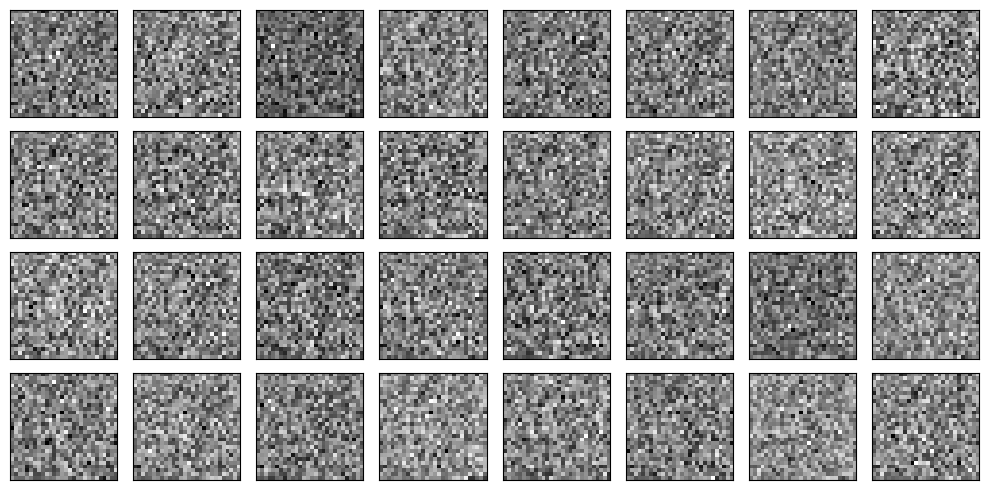

<Figure size 640x480 with 0 Axes>

[Epoch 0/50] [Batch 50/938] [D loss: 0.6275] [G loss: 0.6762]
[Epoch 0/50] [Batch 100/938] [D loss: 0.6000] [G loss: 0.7945]
[Epoch 0/50] [Batch 150/938] [D loss: 0.6517] [G loss: 0.6728]
[Epoch 0/50] [Batch 200/938] [D loss: 0.5320] [G loss: 1.1557]
[Epoch 0/50] [Batch 250/938] [D loss: 0.6145] [G loss: 0.8649]
[Epoch 0/50] [Batch 300/938] [D loss: 0.5766] [G loss: 1.0190]
[Epoch 0/50] [Batch 350/938] [D loss: 0.4432] [G loss: 1.2094]
[Epoch 0/50] [Batch 400/938] [D loss: 0.4519] [G loss: 1.1671]


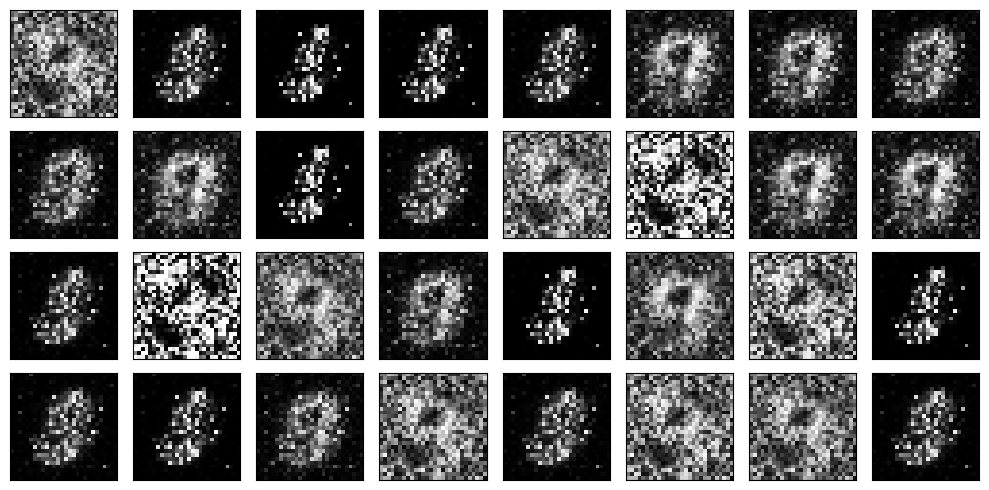

<Figure size 640x480 with 0 Axes>

[Epoch 0/50] [Batch 450/938] [D loss: 0.5769] [G loss: 1.0727]
[Epoch 0/50] [Batch 500/938] [D loss: 0.5884] [G loss: 0.7134]
[Epoch 0/50] [Batch 550/938] [D loss: 0.6376] [G loss: 1.6231]
[Epoch 0/50] [Batch 600/938] [D loss: 0.6144] [G loss: 0.9865]
[Epoch 0/50] [Batch 650/938] [D loss: 0.6172] [G loss: 0.8974]
[Epoch 0/50] [Batch 700/938] [D loss: 0.4488] [G loss: 1.4967]
[Epoch 0/50] [Batch 750/938] [D loss: 0.5051] [G loss: 1.7033]
[Epoch 0/50] [Batch 800/938] [D loss: 0.5413] [G loss: 1.0564]


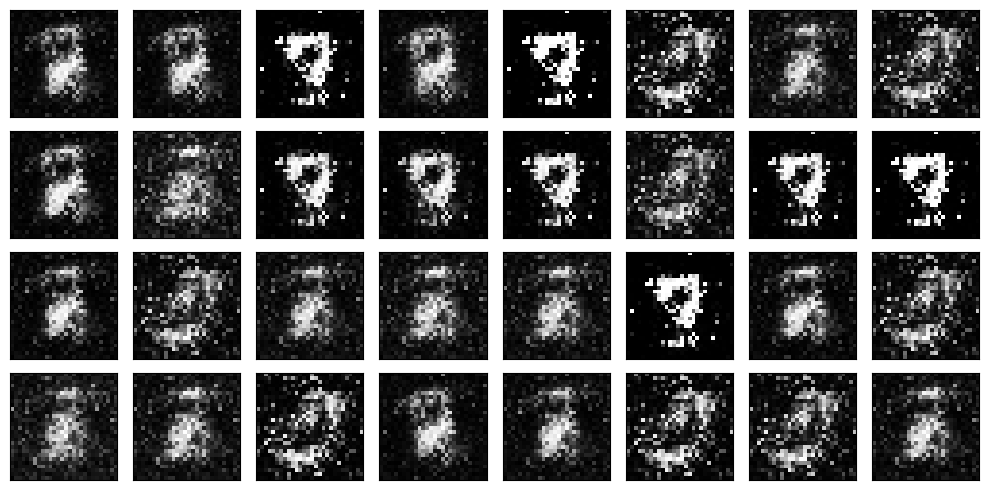

<Figure size 640x480 with 0 Axes>

[Epoch 0/50] [Batch 850/938] [D loss: 0.5509] [G loss: 1.8094]
[Epoch 0/50] [Batch 900/938] [D loss: 0.4461] [G loss: 1.6420]
[Epoch 1/50] [Batch 0/938] [D loss: 0.6687] [G loss: 2.4796]
[Epoch 1/50] [Batch 50/938] [D loss: 0.4242] [G loss: 1.8542]
[Epoch 1/50] [Batch 100/938] [D loss: 0.6797] [G loss: 0.6943]
[Epoch 1/50] [Batch 150/938] [D loss: 0.3936] [G loss: 1.6909]
[Epoch 1/50] [Batch 200/938] [D loss: 0.5788] [G loss: 0.8794]
[Epoch 1/50] [Batch 250/938] [D loss: 0.4913] [G loss: 1.1535]


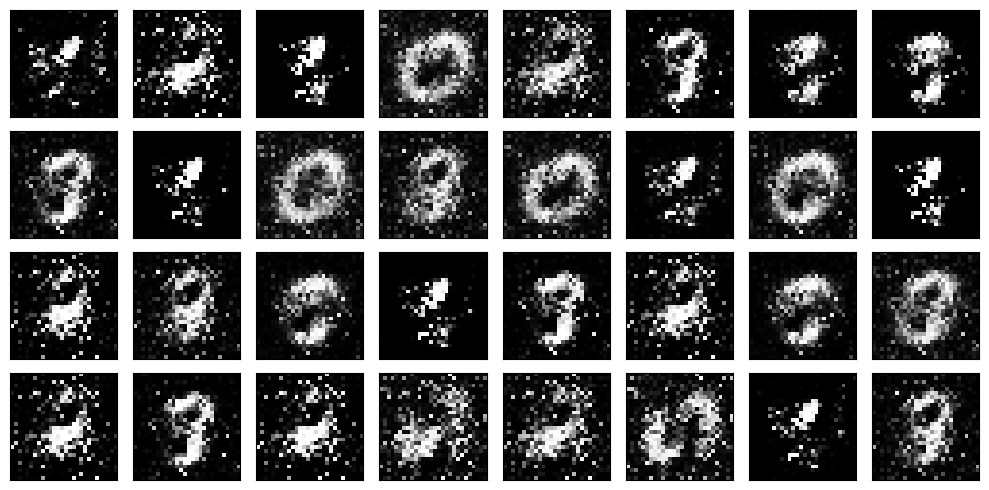

<Figure size 640x480 with 0 Axes>

[Epoch 1/50] [Batch 300/938] [D loss: 0.3853] [G loss: 1.3914]
[Epoch 1/50] [Batch 350/938] [D loss: 0.4127] [G loss: 2.0793]
[Epoch 1/50] [Batch 400/938] [D loss: 0.5025] [G loss: 1.1116]
[Epoch 1/50] [Batch 450/938] [D loss: 0.4726] [G loss: 1.3722]
[Epoch 1/50] [Batch 500/938] [D loss: 0.5562] [G loss: 1.7115]
[Epoch 1/50] [Batch 550/938] [D loss: 0.4857] [G loss: 1.9293]
[Epoch 1/50] [Batch 600/938] [D loss: 0.4734] [G loss: 1.5185]
[Epoch 1/50] [Batch 650/938] [D loss: 0.4833] [G loss: 0.9416]


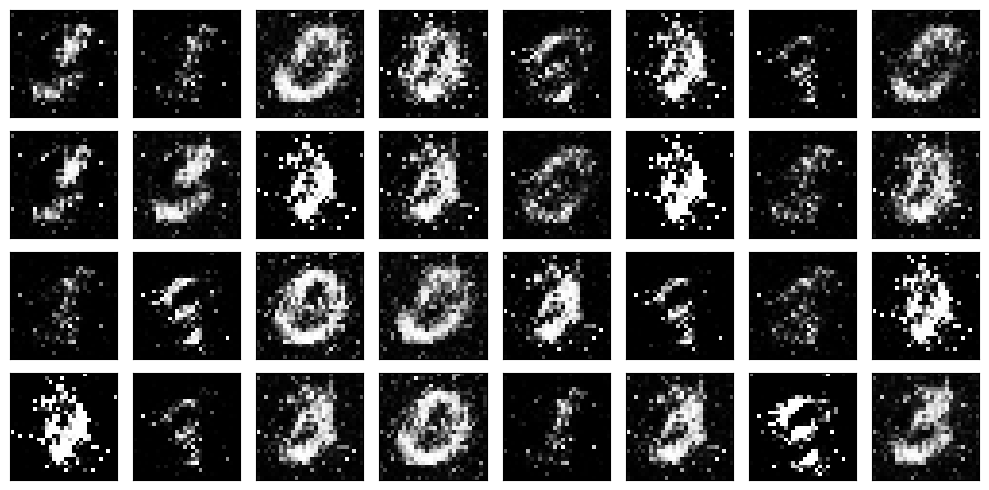

<Figure size 640x480 with 0 Axes>

[Epoch 1/50] [Batch 700/938] [D loss: 0.4371] [G loss: 1.2546]
[Epoch 1/50] [Batch 750/938] [D loss: 0.5013] [G loss: 1.2028]
[Epoch 1/50] [Batch 800/938] [D loss: 0.4237] [G loss: 1.0674]
[Epoch 1/50] [Batch 850/938] [D loss: 0.5283] [G loss: 0.8803]
[Epoch 1/50] [Batch 900/938] [D loss: 0.6003] [G loss: 0.6725]
[Epoch 2/50] [Batch 0/938] [D loss: 0.5460] [G loss: 2.5836]
[Epoch 2/50] [Batch 50/938] [D loss: 0.6224] [G loss: 2.3429]
[Epoch 2/50] [Batch 100/938] [D loss: 0.3683] [G loss: 1.6122]


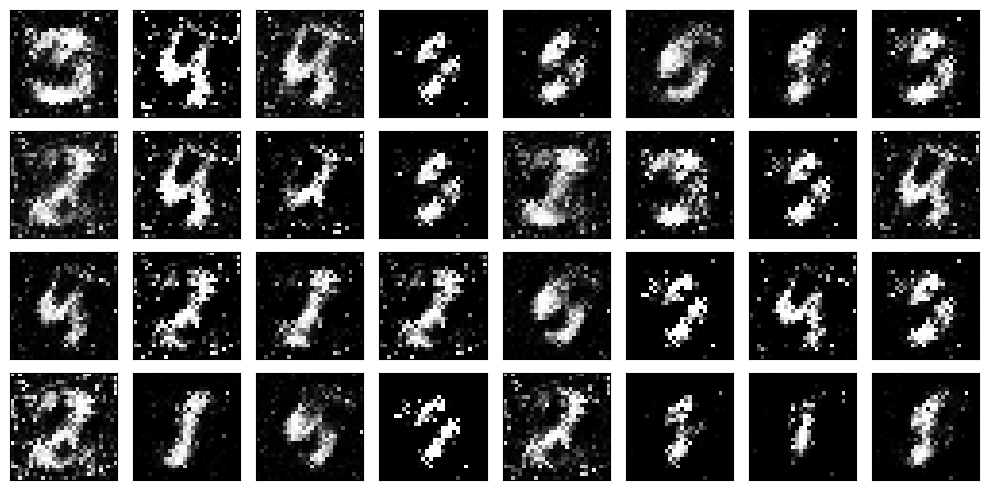

<Figure size 640x480 with 0 Axes>

[Epoch 2/50] [Batch 150/938] [D loss: 0.4013] [G loss: 1.6682]
[Epoch 2/50] [Batch 200/938] [D loss: 0.4734] [G loss: 1.3965]
[Epoch 2/50] [Batch 250/938] [D loss: 0.4506] [G loss: 2.3462]
[Epoch 2/50] [Batch 300/938] [D loss: 0.4458] [G loss: 1.1610]
[Epoch 2/50] [Batch 350/938] [D loss: 0.3748] [G loss: 2.4502]
[Epoch 2/50] [Batch 400/938] [D loss: 0.6318] [G loss: 0.5547]
[Epoch 2/50] [Batch 450/938] [D loss: 0.3961] [G loss: 2.3065]
[Epoch 2/50] [Batch 500/938] [D loss: 0.4781] [G loss: 2.2777]


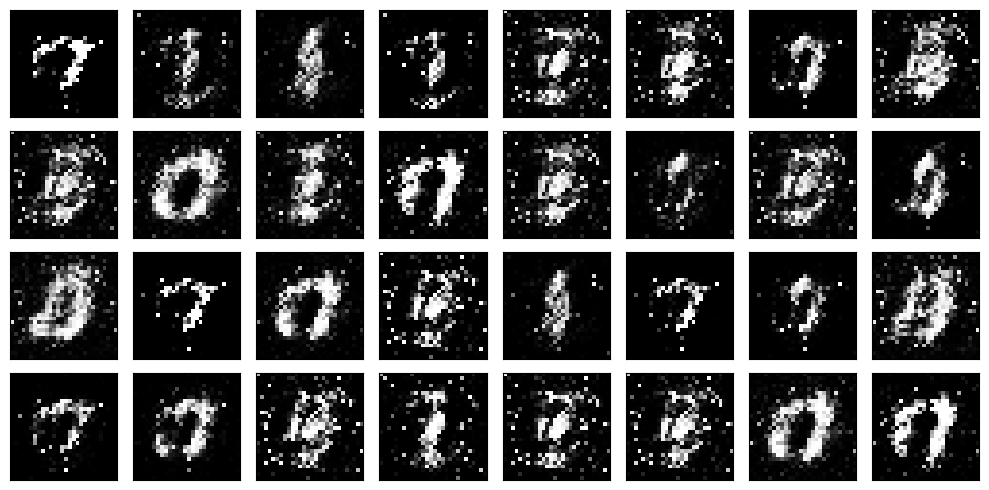

<Figure size 640x480 with 0 Axes>

[Epoch 2/50] [Batch 550/938] [D loss: 0.4694] [G loss: 2.4335]
[Epoch 2/50] [Batch 600/938] [D loss: 0.4219] [G loss: 2.6820]
[Epoch 2/50] [Batch 650/938] [D loss: 0.4133] [G loss: 1.2429]
[Epoch 2/50] [Batch 700/938] [D loss: 0.4069] [G loss: 1.9044]
[Epoch 2/50] [Batch 750/938] [D loss: 0.6453] [G loss: 3.3723]
[Epoch 2/50] [Batch 800/938] [D loss: 0.3263] [G loss: 1.9591]
[Epoch 2/50] [Batch 850/938] [D loss: 0.4415] [G loss: 0.8817]


In [ ]:
num_epochs = 50 # You can adjust this
sample_interval = 400 # How often to save generated images

# Lists to store losses for plotting
d_losses = []
g_losses = []

print("Starting GAN training...")

for epoch in range(num_epochs):
    for i, (imgs, _) in enumerate(train_loader):

        # Adversarial ground truths
        valid = torch.ones(imgs.size(0), 1, device=device)
        fake = torch.zeros(imgs.size(0), 1, device=device)

        # Configure input
        real_imgs = imgs.to(device)

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Sample noise as generator input
        z = torch.randn(imgs.size(0), latent_dim, device=device)

        # Generate a batch of images
        gen_imgs = generator(z)

        # Measure discriminator's ability to classify real and fake images
        real_loss = adversarial_loss(discriminator(real_imgs), valid)
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        # -----------------
        #  Train Generator
        # -----------------

        optimizer_G.zero_grad()

        # Generate a batch of images
        gen_imgs = generator(z)

        # Loss measures generator's ability to fool discriminator
        g_loss = adversarial_loss(discriminator(gen_imgs), valid)

        g_loss.backward()
        optimizer_G.step()

        # --------------
        # Log Progress
        # --------------
        if i % 50 == 0:
            print(
                f"[Epoch {epoch}/{num_epochs}] [Batch {i}/{len(train_loader)}] "
                f"[D loss: {d_loss.item():.4f}] [G loss: {g_loss.item():.4f}]"
            )

        # Save losses for plotting
        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())

        batches_done = epoch * len(train_loader) + i
        if batches_done % sample_interval == 0:
            # Save generated images
            show_images(gen_imgs.data[:32], num_rows=4, num_cols=8, figsize=(10, 5))
            plt.suptitle(f"Epoch {epoch}, Batch {i}")
            plt.show()

print("Training finished.")

### 6. Visualize Training Losses

In [ ]:
# Plot the generator and discriminator losses
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.title('GAN Training Losses')
plt.legend()
plt.grid(True)
plt.show()